In [2]:
import torch
import torch.nn as nn


In [33]:
device = torch.device("cpu")
if(torch.cuda.is_available()):
    device = torch.device("cuda")
if(torch.backends.mps.is_available()):
    device = torch.device("mps")

print('Using device:', device)

LEARNING_RATE = 0.001
BATCH_SIZE = 256
NUM_EPOCHS = 100

Using device: mps


In [17]:
import torchvision
from torchvision import transforms, datasets
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
#load data


train_transform = transforms.Compose(
    [torchvision.transforms.ToTensor(), torch.flatten])
test_transform =  transforms.Compose(
    [torchvision.transforms.ToTensor(), torch.flatten])

train_data = MNIST(root='data', train=True, download=True, transform=train_transform)
test_data = MNIST(root='data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# check data loader 

for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

for images, labels in test_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])
Image batch dimensions: torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])


In [12]:


class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
        )
    
        self.z_mean = nn.Linear(128, 2)
        self.z_log_var = nn.Linear(128, 2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def reparameterize(self, z_mu, z_log_var):
        esp = torch.randn(z_mu.shape[0], z_mu.shape[1]).to(device)
        z = z_mu + esp * torch.exp(z_log_var/2.)
        return z
    
    def encoding(self, x):
        x = self.encoder(x)
        z_mean,z_log_var = self.z_mean(x),self.z_log_var(x)
        encoded = self.reparameterize(z_mean,z_log_var)
        return encoded

    def forward(self,x):
        x = self.encoder(x)
        z_mean,z_log_var = self.z_mean(x),self.z_log_var(x)
        encoded = self.reparameterize(z_mean,z_log_var)
        decoded = self.decoder(encoded)
        return encoded, z_mean, z_log_var,decoded

In [13]:
model = VAE()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [35]:
import time
import torch.nn.functional as Functional

losses = []
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx, (features, _) in enumerate(train_loader):
        features = features.to(device)

        encoded, z_mean, z_log_var, decoded = model(features)
        kl_div = -0.5 * torch.sum(1 + z_log_var  - z_mean**2  - torch.exp(z_log_var), axis=1) # sum over latent dimension
        batchsize = kl_div.size(0)
        kl_div = torch.mean(kl_div)

        reconstruction_loss = Functional.mse_loss(decoded, features, reduction='none') # sum over all pixels
        reconstruction_loss = reconstruction_loss.view(batchsize, -1).sum(axis=1)
        reconstruction_loss = reconstruction_loss.mean()

        loss = kl_div + reconstruction_loss
        total_loss += loss
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    losses.append(total_loss/len(train_loader))
    if(epoch%10==0):
        print("Epoch: %d, Loss: %f" % (epoch, total_loss / len(train_loader)))

Epoch: 0, Loss: 33.721432
Epoch: 10, Loss: 33.681347
Epoch: 20, Loss: 33.645039
Epoch: 30, Loss: 33.577633
Epoch: 40, Loss: 33.575588
Epoch: 50, Loss: 33.551704
Epoch: 60, Loss: 33.509106
Epoch: 70, Loss: 33.445309
Epoch: 80, Loss: 33.411800
Epoch: 90, Loss: 33.425919


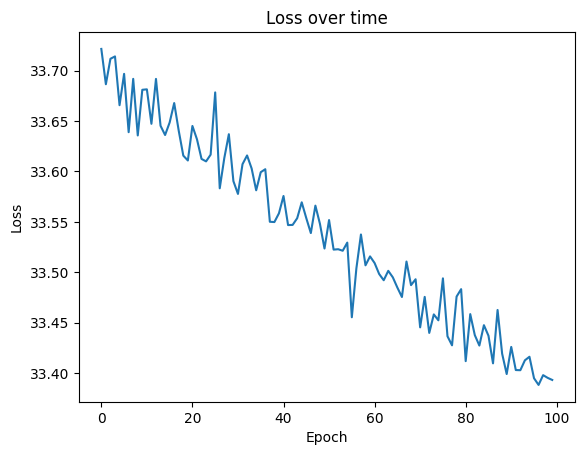

In [36]:
import matplotlib.pyplot as plt
# plot loss over time
losses_cpu = [loss.cpu().detach().numpy() for loss in losses]

plt.plot(losses_cpu)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over time')
plt.show()

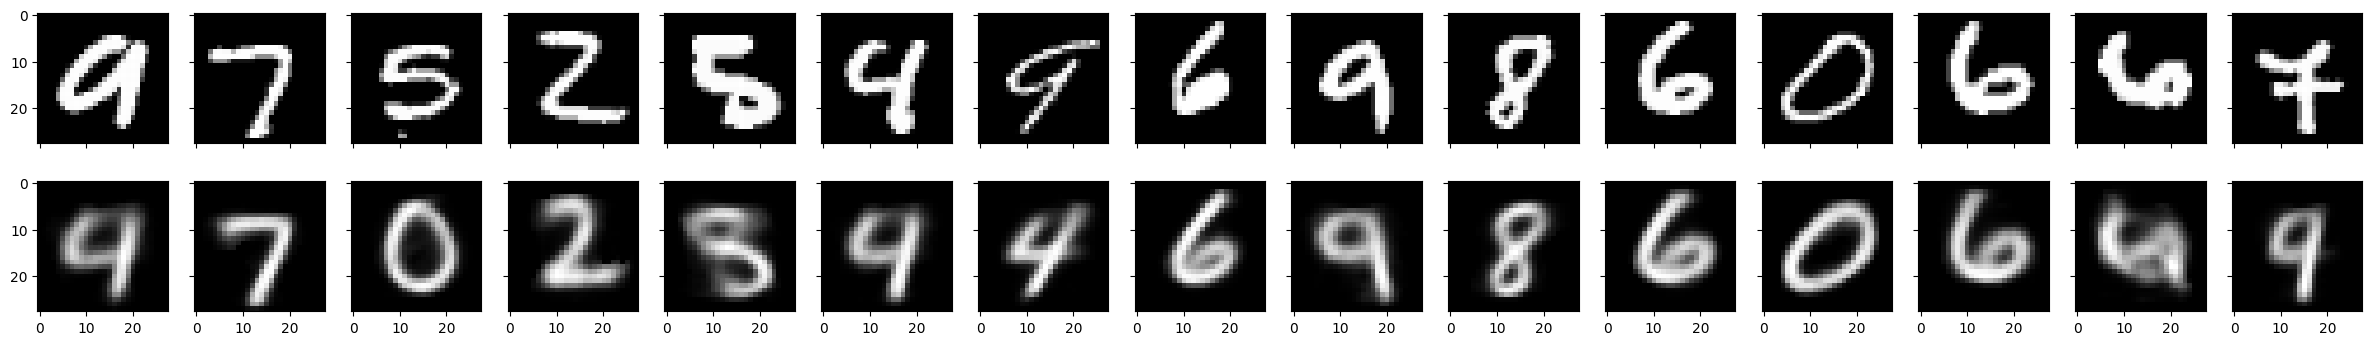

In [37]:
fig,axes = plt.subplots(nrows=2,ncols=15,sharex=True,sharey=True,figsize=(30,4))
for batch_idx, (features, _) in enumerate(train_loader):
    features = features.to(device)
    with torch.no_grad():
        encoded, z_mean, z_log_var, decoded = model(features)[:15]
    origin_img = features[:15]
    break
for i in range(15):
    axes[0, i].imshow(origin_img[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1,i].imshow(decoded[i].cpu().detach().numpy().reshape(28,28),cmap='gray')